In [28]:
import os


## Dataset

In [29]:
ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]

with open(os.path.join("datasets", "CUB", "CUB_200_2011", "attributes.txt"), 'r') as f:
    all_attributes_orig_idx = {}
    
    lines = f.readlines()
    for line in lines:
        idx, attr_name = line.strip().split(" ")
        #attr_group, attr_name = attr_name.split("::")  
        # 0-based indexing
        all_attributes_orig_idx[int(idx) - 1] = attr_name
  
# Map between 112 concept idx and attribute name      
sample_112_concepts_map = {new_idx: all_attributes_orig_idx[orig_idx] for new_idx, orig_idx in enumerate(ATTRIBUTES_IDX_USED)}
attr_groups__112_concepts = list(set(attr_name.split("::")[0] for attr_name in sample_112_concepts_map.values()))

print(sample_112_concepts_map)
print(attr_groups__112_concepts)
print(len(attr_groups__112_concepts))


{0: 'has_bill_shape::dagger', 1: 'has_bill_shape::hooked_seabird', 2: 'has_bill_shape::all-purpose', 3: 'has_bill_shape::cone', 4: 'has_wing_color::brown', 5: 'has_wing_color::grey', 6: 'has_wing_color::yellow', 7: 'has_wing_color::black', 8: 'has_wing_color::white', 9: 'has_wing_color::buff', 10: 'has_upperparts_color::brown', 11: 'has_upperparts_color::grey', 12: 'has_upperparts_color::yellow', 13: 'has_upperparts_color::black', 14: 'has_upperparts_color::white', 15: 'has_upperparts_color::buff', 16: 'has_underparts_color::brown', 17: 'has_underparts_color::grey', 18: 'has_underparts_color::yellow', 19: 'has_underparts_color::black', 20: 'has_underparts_color::white', 21: 'has_underparts_color::buff', 22: 'has_breast_pattern::solid', 23: 'has_breast_pattern::striped', 24: 'has_breast_pattern::multi-colored', 25: 'has_back_color::brown', 26: 'has_back_color::grey', 27: 'has_back_color::yellow', 28: 'has_back_color::black', 29: 'has_back_color::white', 30: 'has_back_color::buff', 31: '

In [30]:
# Read dataset dir from the log file in the experiment path
import ast
import pandas as pd


info_dataset_path = os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", "info.txt")


with open(info_dataset_path, 'r') as f:
    lines = f.readlines()

    for line in lines:
        if "New attribute indices mapping: " in line:
            new_attribute_mapping_string = line.split("New attribute indices mapping: ")[1].strip()
            
        if "Removed attribute groups: " in line:
            removed_attribute_groups_string = line.split("Removed attribute groups: ")[1].strip()
            

# Original has 112 attributes, but we only use a subset of them
new_attribute_mapping = ast.literal_eval(new_attribute_mapping_string)

# Removed groups list
removed_attribute_groups = ast.literal_eval(removed_attribute_groups_string)
    

        
        
concept_names_new_idx_map = {}
for orig_idx, new_idx in new_attribute_mapping.items():
    concept_names_new_idx_map[new_idx] = sample_112_concepts_map[orig_idx]


df = pd.DataFrame(list(concept_names_new_idx_map.items()), columns=['New Index', 'Concept Name'])
df.to_csv("delete_afterwards/concept_names_new_idx_map.csv", index=False)
display(df.sort_values(by='New Index').reset_index(drop=True))

# Number of attrbutes removed
print(f"Number of attributes removed: {112 - len(concept_names_new_idx_map.keys())}")





,New Index,Concept Name
0,0,has_bill_shape::dagger
1,1,has_bill_shape::hooked_seabird
2,2,has_bill_shape::all-purpose
3,3,has_bill_shape::cone
4,4,has_head_pattern::eyebrow
5,5,has_head_pattern::plain
6,6,has_breast_color::brown
7,7,has_breast_color::grey
8,8,has_breast_color::yellow
9,9,has_breast_color::black


Number of attributes removed: 90


## Intervention curves

SCBM                   seeds [0, 10, 20]  curves (3, 23)  [22 concepts, 200 classes, Mateo_025]
Res-SCBM               seeds [0, 10, 20]  curves (3, 23)  [22 concepts, 200 classes, Mateo_025]
IntRes-SCBM            seeds [0, 10, 20]  curves (3, 23)  [22 concepts, 200 classes, Mateo_025]
Hard CBM               seeds [0, 10, 20]  curves (3, 23)  [22 concepts, 200 classes, Mateo_025]
CEM                    seeds [0, 10, 20]  curves (3, 23)  [22 concepts, 200 classes, Mateo_025]
Linear head (GT concepts) seeds [0, 10, 20]  test acc [84.66, 85.73, 84.35]


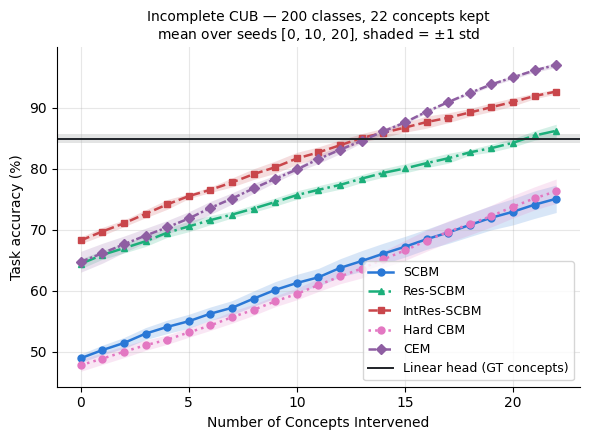

In [31]:
import re
import ast
import glob
import numpy as np
import matplotlib.pyplot as plt

# (label, model_type, run_dir_glob) -- one entry per model, each glob matching that
# model's 3 seed runs under experiments/<model_type>/CUB/. The globs are anchored on the
# save_name prefix so they cannot collide: the plain Res-SCBM runs are
# "Mateo_025_fixed_residuals_20_*", the L_int ones carry the extra
# "emp_perc_..._L_int_extension_loss_weight_1" tag.
CUB_MODELS = [
    ("SCBM",                 "scbm",          "Mateo_025_2026-*"),
    ("Res-SCBM",             "scbm_residual", "Mateo_025_fixed_residuals_20_2026-*"),
    ("IntRes-SCBM", "scbm_residual",
     "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-*"),
    ("Hard CBM",             "cbm",           "hard_cbm_Mateo_025_2026-*"),
    # CEM is the only model here trained *on* interventions (RandInt, model.p_int=0.25),
    # so its slope with concept count is not a like-for-like comparison against the rest.
    ("CEM", "cbm",  "cem_p_int_0.25_Mateo_025_2026-*"),
]

COLORS = {
    "SCBM": "#2a78d6",
    "Res-SCBM": "#1baf7a",
    "IntRes-SCBM": "#c9464b",
    "Hard CBM": "#e377c2",
    "CEM": "#8e5ea2",
}
MARKERS = {"SCBM": "o", "Res-SCBM": "^", "IntRes-SCBM": "s", "Hard CBM": "o",
           "CEM": "D"}
LINESTYLES = {"SCBM": "-", "Res-SCBM": "-.", "IntRes-SCBM": "--", "Hard CBM": ":",
              "CEM": (0, (3, 1, 1, 1))}

# Ground-truth reference: nn.Linear(num_concepts, num_classes) trained by eval_datasets.py
# on the *true* labels of the kept concepts of the same split -- the accuracy the kept
# concepts alone support. It has no concept predictions and hence no intervention sweep:
# one test accuracy per seed, drawn as a flat line. The older seedless run
# (Mateo_025_2026-05-06_*) is deliberately not matched.
GT_LABEL = "Linear head (GT concepts)"
GT_GLOB = "Mateo_025_2026-*_seed_*"
GT_COLOR = "#1f2328"

EXPECTED_SEEDS = {0, 10, 20}
BAND = "std"  # "std" -> mean +/- 1 std across seeds; "minmax" -> full seed range


def read_run_config(run_path):
    """First line of log.txt is the full config dict."""
    with open(os.path.join(run_path, "log.txt"), "r") as f:
        return ast.literal_eval(f.readline().strip())


def parse_intervention_log(log_txt_path):
    """Return (xs, rows) with rows[i] a {metric: value} dict for xs[i] concepts intervened.

    Keyed by concept count so that a log containing a partial sweep followed by a
    re-run keeps the *last* value written.
    """
    curve = {}
    with open(log_txt_path, "r") as f:
        for line in f:
            m = re.search(r"Intervention on (\d+) concepts", line)
            if not m or "y_accuracy" not in line:
                continue
            curve[int(m.group(1))] = {
                k: float(v) for k, v in re.findall(r"([A-Za-z_\-]+):\s*([0-9.]+)", line)
            }
    xs = sorted(curve)
    return xs, [curve[x] for x in xs]


def collect_model(label, model_type, run_glob, dataset="CUB", metric="y_accuracy"):
    """Stack one model's per-seed intervention curves into an (n_seeds, n_points) array."""
    run_paths = sorted(glob.glob(os.path.join("experiments", model_type, dataset, run_glob)))
    seeds, curves, run_dirs, xs_ref, shapes = [], [], [], None, set()
    for run_path in run_paths:
        log_txt = os.path.join(run_path, "intervention_log.txt")
        if not os.path.exists(log_txt):
            continue
        cfg = read_run_config(run_path)
        xs, rows = parse_intervention_log(log_txt)
        if xs_ref is None:
            xs_ref = xs
        assert xs == xs_ref, f"{run_path}: intervention grid differs from the other seeds"
        # Seeds are only comparable if they were trained on the same incomplete split.
        # Complete AwA2 runs log pkl_file_dir=None (no split folder); name that "complete".
        shapes.add((cfg["data"]["num_classes"], cfg["data"]["num_concepts"],
                    (cfg["data"]["pkl_file_dir"] or "complete").rstrip("/")))
        seeds.append(cfg["seed"])
        curves.append([r[metric] * 100 for r in rows])
        run_dirs.append(os.path.basename(run_path))
    assert set(seeds) == EXPECTED_SEEDS, \
        f"{label} ({dataset}/{run_glob}): found seeds {sorted(seeds)}, expected {sorted(EXPECTED_SEEDS)}"
    assert len(shapes) == 1, f"{label}: seeds disagree on classes/concepts/split: {shapes}"
    return {"label": label, "model_type": model_type, "seeds": sorted(seeds),
            "run_dirs": run_dirs, "shape": shapes.pop(),
            "x": np.array(xs_ref), "y": np.array(curves)}


def collect_linear_head(run_glob, dataset, shape):
    """Per-seed test target accuracy (%) of the ground-truth-concept linear head.

    eval_datasets.py writes a slimmer log than train.py: line 1 is a flat info dict (no
    nested "data", no "seed"), the seed is only in the folder name, and the result is a
    single "Final Test Accuracy" line. `shape` is the (classes, concepts, split) of the
    models it is compared against.
    """
    seeds, accs, run_dirs = [], [], []
    for run_path in sorted(glob.glob(os.path.join("experiments", "linear_head", dataset, run_glob))):
        info = read_run_config(run_path)
        assert info["model_type"] == "linear_head" and not info["use_residuals_from_data"], run_path
        run_shape = (info["num_classes"], info["num_concepts"], info["pkl_file_dir"].rstrip("/"))
        assert run_shape == shape, f"{run_path}: trained on {run_shape}, models are on {shape}"
        seeds.append(int(re.search(r"_seed_(\d+)_", os.path.basename(run_path)).group(1)))
        found = re.findall(r"Final Test Accuracy:\s*([0-9.]+)",
                           open(os.path.join(run_path, "log.txt")).read())
        assert len(found) == 1, f"{run_path}: expected 1 'Final Test Accuracy', found {len(found)}"
        accs.append(float(found[0]) * 100)
        run_dirs.append(os.path.basename(run_path))
    assert sorted(seeds) == sorted(EXPECTED_SEEDS), \
        f"{GT_LABEL}: found seeds {sorted(seeds)}, expected {sorted(EXPECTED_SEEDS)}"
    return {"label": GT_LABEL, "seeds": sorted(seeds), "run_dirs": run_dirs, "y": np.array(accs)}


def gt_band(gt):
    """(mean, lo, hi) of the linear head's seed accuracies, same BAND rule as the curves."""
    mean = gt["y"].mean()
    if BAND == "std":
        # A single-run reference (the complete datasets) has no seed spread: zero-width band.
        sd = gt["y"].std(ddof=1) if len(gt["y"]) > 1 else 0.0
        return mean, mean - sd, mean + sd
    return mean, gt["y"].min(), gt["y"].max()


metric = "y_accuracy"
models = [collect_model(*m, metric=metric) for m in CUB_MODELS]
for m in models:
    n_classes, n_concepts, pkl_dir = m["shape"]
    print(f"{m['label']:<22} seeds {m['seeds']}  curves {m['y'].shape}  "
          f"[{n_concepts} concepts, {n_classes} classes, {pkl_dir}]")
# One x-axis only makes sense if every model saw the same concept set.
assert len({m["shape"] for m in models}) == 1, "models are not on the same CUB setup"
assert all((m["x"] == models[0]["x"]).all() for m in models), "models differ in x grid"

gt = collect_linear_head(GT_GLOB, "CUB", models[0]["shape"])
print(f"{GT_LABEL:<22} seeds {gt['seeds']}  test acc {np.round(gt['y'], 2).tolist()}")

fig, ax = plt.subplots(figsize=(6.0, 4.5))
for m in models:
    mean = m["y"].mean(axis=0)
    if BAND == "std":
        band_lo, band_hi = mean - m["y"].std(axis=0, ddof=1), mean + m["y"].std(axis=0, ddof=1)
    else:
        band_lo, band_hi = m["y"].min(axis=0), m["y"].max(axis=0)
    color = COLORS[m["label"]]
    ax.fill_between(m["x"], band_lo, band_hi, color=color, alpha=0.18, linewidth=0)
    ax.plot(m["x"], mean, marker=MARKERS[m["label"]], ms=5, lw=1.8,
            linestyle=LINESTYLES[m["label"]], color=color, label=m["label"])

gt_mean, gt_lo, gt_hi = gt_band(gt)
ax.axhspan(gt_lo, gt_hi, color=GT_COLOR, alpha=0.12, linewidth=0)
ax.axhline(gt_mean, color=GT_COLOR, lw=1.4, label=GT_LABEL)

n_classes, n_concepts, _ = models[0]["shape"]
ax.set_xlabel("Number of Concepts Intervened")
ax.set_ylabel("Task accuracy (%)")
ax.set_title(f"Incomplete CUB — {n_classes} classes, {n_concepts} concepts kept\n"
             f"mean over seeds {models[0]['seeds']}, shaded = "
             + ("$\\pm$1 std" if BAND == "std" else "min-max range"), fontsize=10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join("plots", "cub_incomplete_intervention_curves.png"), dpi=200,
            bbox_inches="tight")
plt.show()

## Test accuracy table

In [32]:
# Test-set concept / target accuracy, mean +/- std over the 3 seeds of each model.
#
# Source is the single "Test:" line of each run's log.txt (the best-validation checkpoint
# evaluated on the test split), NOT the 0-intervention row of intervention_log.txt: the
# two differ slightly because the intervention sweep re-samples the concept logits.
# Reuses CUB_MODELS / read_run_config / EXPECTED_SEEDS / gt from the intervention-curve cell.
# The ground-truth linear head is appended as a separate reference row: it has no concept
# accuracy ("—") and is excluded from the best / runner-up marking.

TABLE_ORDER = [
    "Hard CBM",
    "CEM",
    "SCBM",
    "Res-SCBM",
    "IntRes-SCBM",
]
TABLE_NAMES = {  # plain names for the table, without the plot's mathtext
}
METRICS = [("c_accuracy", "Concept Accuracy"), ("y_accuracy", "Target Accuracy")]


def parse_test_line(run_path):
    """Parse the run's single 'Test:' line from log.txt into a {metric: value} dict."""
    test_lines = [l for l in open(os.path.join(run_path, "log.txt")) if l.startswith("Test:")]
    assert len(test_lines) == 1, f"{run_path}: expected 1 'Test:' line, found {len(test_lines)}"
    return {k: float(v) for k, v in re.findall(r"([A-Za-z_\-]+):\s*([0-9.]+)", test_lines[0])}


def collect_test_metrics(label, model_type, run_glob, dataset="CUB"):
    """Per-seed test metrics for one model, as {metric: np.array of len n_seeds}."""
    seeds, rows = [], []
    for run_path in sorted(glob.glob(os.path.join("experiments", model_type, dataset, run_glob))):
        seeds.append(read_run_config(run_path)["seed"])
        rows.append(parse_test_line(run_path))
    assert set(seeds) == EXPECTED_SEEDS, \
        f"{label}: found seeds {sorted(seeds)}, expected {sorted(EXPECTED_SEEDS)}"
    return {m: np.array([r[m] * 100 for r in rows]) for m, _ in METRICS}


specs = {label: (label, mt, g) for label, mt, g in CUB_MODELS}
stats = {label: collect_test_metrics(*specs[label]) for label in TABLE_ORDER}

table = pd.DataFrame(
    {col: [f"{stats[l][m].mean():.2f} ± {stats[l][m].std(ddof=1):.2f}" for l in TABLE_ORDER]
     for m, col in METRICS},
    index=[TABLE_NAMES.get(l, l) for l in TABLE_ORDER],
)
table.loc[GT_LABEL] = [f"{gt['y'].mean():.2f} ± {gt['y'].std(ddof=1):.2f}"
                       if m == "y_accuracy" else "—" for m, _ in METRICS]
table.index.name = "Method"
display(table)

# LaTeX version: best in bold, runner-up underlined, as in the SCBM paper's table.
latex_rows = []
for label in TABLE_ORDER:
    cells = []
    for m, _ in METRICS:
        means = np.array([stats[l][m].mean() for l in TABLE_ORDER])
        rank = means.argsort()[::-1]          # descending; higher accuracy is better
        best, second = TABLE_ORDER[rank[0]], TABLE_ORDER[rank[1]]
        cell = f"{stats[label][m].mean():.2f} $\\pm$ {stats[label][m].std(ddof=1):.2f}"
        if label == best:
            cell = f"\\textbf{{{cell}}}"
        elif label == second:
            cell = f"\\underline{{{cell}}}"
        cells.append(cell)
    latex_rows.append(f"{TABLE_NAMES.get(label, label)} & " + " & ".join(cells) + r" \\")
gt_cells = [f"{gt['y'].mean():.2f} $\\pm$ {gt['y'].std(ddof=1):.2f}"
            if m == "y_accuracy" else "--" for m, _ in METRICS]

print("\n% Incomplete CUB (Mateo_025), test split, mean $\\pm$ std over 3 seeds")
print(r"\begin{tabular}{lcc}")
print(r"\toprule")
print(r"Method & Concept Accuracy & Target Accuracy \\")
print(r"\midrule")
print("\n".join(latex_rows))
print(r"\midrule")
print(f"{GT_LABEL} & " + " & ".join(gt_cells) + r" \\")
print(r"\bottomrule")
print(r"\end{tabular}")

,Concept Accuracy,Target Accuracy
Method,,
Hard CBM,94.33 ± 0.15,47.87 ± 1.00
CEM,94.17 ± 0.32,64.77 ± 1.71
SCBM,94.57 ± 0.06,49.03 ± 0.71
Res-SCBM,94.67 ± 0.12,64.43 ± 0.72
IntRes-SCBM,94.90 ± 0.10,68.20 ± 0.69
Linear head (GT concepts),—,84.91 ± 0.72



% Incomplete CUB (Mateo_025), test split, mean $\pm$ std over 3 seeds
\begin{tabular}{lcc}
\toprule
Method & Concept Accuracy & Target Accuracy \\
\midrule
Hard CBM & 94.33 $\pm$ 0.15 & 47.87 $\pm$ 1.00 \\
CEM & 94.17 $\pm$ 0.32 & \underline{64.77 $\pm$ 1.71} \\
SCBM & 94.57 $\pm$ 0.06 & 49.03 $\pm$ 0.71 \\
Res-SCBM & \underline{94.67 $\pm$ 0.12} & 64.43 $\pm$ 0.72 \\
IntRes-SCBM & \textbf{94.90 $\pm$ 0.10} & \textbf{68.20 $\pm$ 0.69} \\
\midrule
Linear head (GT concepts) & -- & 84.91 $\pm$ 0.72 \\
\bottomrule
\end{tabular}


## Target accuracy under intervention

In [33]:
# Target accuracy at selected points along the intervention sweep -- the tabular form of
# the curve above. Mean +/- std over the 3 seeds, read from the same intervention_log.txt
# curves (`models`), so these numbers match the plot exactly (and sit a few tenths off the
# "Test:" row of the table above, which re-uses a different concept-logit sample).
# Reuses `models` / `gt` from the intervention-curve cell and TABLE_ORDER / TABLE_NAMES from
# the test-accuracy cell. The ground-truth linear head is the same value in every column
# (it takes no predicted concepts, so there is nothing to intervene on) and is kept out of
# the best / runner-up marking.

INTERVENTION_POINTS = [0, 5, 10, 15, 20, 22]  # all 22 kept concepts is the full sweep

by_label = {m["label"]: m for m in models}
x_grid = list(models[0]["x"])
missing = [k for k in INTERVENTION_POINTS if k not in x_grid]
assert not missing, f"no sweep point for {missing}; grid is {x_grid[0]}..{x_grid[-1]}"
cols = [x_grid.index(k) for k in INTERVENTION_POINTS]

# (n_methods, n_points) mean/std of target accuracy, rows in TABLE_ORDER
means = np.array([by_label[l]["y"][:, cols].mean(axis=0) for l in TABLE_ORDER])
stds = np.array([by_label[l]["y"][:, cols].std(axis=0, ddof=1) for l in TABLE_ORDER])

int_table = pd.DataFrame(
    [[f"{mu:.2f} ± {sd:.2f}" for mu, sd in zip(mu_row, sd_row)]
     for mu_row, sd_row in zip(means, stds)],
    index=[TABLE_NAMES.get(l, l) for l in TABLE_ORDER],
    columns=[f"{k} int." for k in INTERVENTION_POINTS],
)
int_table.loc[GT_LABEL] = [f"{gt['y'].mean():.2f} ± {gt['y'].std(ddof=1):.2f}"] * len(INTERVENTION_POINTS)
int_table.index.name = "Method"
print(f"Target accuracy (%) vs. number of concepts intervened — "
      f"mean ± std over seeds {models[0]['seeds']}")
display(int_table)

# LaTeX version: best per column in bold, runner-up underlined.
rank = (-means).argsort(axis=0)  # descending down each column; higher accuracy is better
latex_rows = []
for i, label in enumerate(TABLE_ORDER):
    cells = []
    for j in range(len(INTERVENTION_POINTS)):
        cell = f"{means[i, j]:.2f} $\\pm$ {stds[i, j]:.2f}"
        if i == rank[0, j]:
            cell = f"\\textbf{{{cell}}}"
        elif i == rank[1, j]:
            cell = f"\\underline{{{cell}}}"
        cells.append(cell)
    latex_rows.append(f"{TABLE_NAMES.get(label, label)} & " + " & ".join(cells) + r" \\")
gt_cell = f"{gt['y'].mean():.2f} $\\pm$ {gt['y'].std(ddof=1):.2f}"

print("\n% Incomplete CUB (Mateo_025), test split, target accuracy under intervention")
print(r"\begin{tabular}{l" + "c" * len(INTERVENTION_POINTS) + "}")
print(r"\toprule")
print(r"& \multicolumn{%d}{c}{Number of concepts intervened} \\" % len(INTERVENTION_POINTS))
print(r"\cmidrule(lr){2-%d}" % (len(INTERVENTION_POINTS) + 1))
print("Method & " + " & ".join(str(k) for k in INTERVENTION_POINTS) + r" \\")
print(r"\midrule")
print("\n".join(latex_rows))
print(r"\midrule")
print(f"{GT_LABEL} & " + " & ".join([gt_cell] * len(INTERVENTION_POINTS)) + r" \\")
print(r"\bottomrule")
print(r"\end{tabular}")

Target accuracy (%) vs. number of concepts intervened — mean ± std over seeds [0, 10, 20]


,0 int.,5 int.,10 int.,15 int.,20 int.,22 int.
Method,,,,,,
Hard CBM,47.83 ± 1.00,53.20 ± 0.79,59.50 ± 0.95,66.63 ± 1.64,73.80 ± 1.85,76.33 ± 2.00
CEM,64.77 ± 1.71,71.87 ± 1.10,79.90 ± 0.44,87.60 ± 0.36,95.00 ± 0.30,97.03 ± 0.42
SCBM,48.97 ± 0.70,55.03 ± 1.14,61.30 ± 1.41,67.23 ± 1.69,72.97 ± 2.15,75.10 ± 2.25
Res-SCBM,64.43 ± 0.81,70.57 ± 0.87,75.70 ± 0.70,80.07 ± 0.75,84.27 ± 0.68,86.23 ± 1.08
IntRes-SCBM,68.27 ± 0.55,75.53 ± 0.40,81.70 ± 1.00,86.77 ± 0.78,90.97 ± 0.67,92.67 ± 0.40
Linear head (GT concepts),84.91 ± 0.72,84.91 ± 0.72,84.91 ± 0.72,84.91 ± 0.72,84.91 ± 0.72,84.91 ± 0.72



% Incomplete CUB (Mateo_025), test split, target accuracy under intervention
\begin{tabular}{lcccccc}
\toprule
& \multicolumn{6}{c}{Number of concepts intervened} \\
\cmidrule(lr){2-7}
Method & 0 & 5 & 10 & 15 & 20 & 22 \\
\midrule
Hard CBM & 47.83 $\pm$ 1.00 & 53.20 $\pm$ 0.79 & 59.50 $\pm$ 0.95 & 66.63 $\pm$ 1.64 & 73.80 $\pm$ 1.85 & 76.33 $\pm$ 2.00 \\
CEM & \underline{64.77 $\pm$ 1.71} & \underline{71.87 $\pm$ 1.10} & \underline{79.90 $\pm$ 0.44} & \textbf{87.60 $\pm$ 0.36} & \textbf{95.00 $\pm$ 0.30} & \textbf{97.03 $\pm$ 0.42} \\
SCBM & 48.97 $\pm$ 0.70 & 55.03 $\pm$ 1.14 & 61.30 $\pm$ 1.41 & 67.23 $\pm$ 1.69 & 72.97 $\pm$ 2.15 & 75.10 $\pm$ 2.25 \\
Res-SCBM & 64.43 $\pm$ 0.81 & 70.57 $\pm$ 0.87 & 75.70 $\pm$ 0.70 & 80.07 $\pm$ 0.75 & 84.27 $\pm$ 0.68 & 86.23 $\pm$ 1.08 \\
IntRes-SCBM & \textbf{68.27 $\pm$ 0.55} & \textbf{75.53 $\pm$ 0.40} & \textbf{81.70 $\pm$ 1.00} & \underline{86.77 $\pm$ 0.78} & \underline{90.97 $\pm$ 0.67} & \underline{92.67 $\pm$ 0.40} \\
\midrule
Linear h

## Combined CUB + AwA2 figure

Paper-style panel in the layout of the SCBM paper's intervention figure: columns are
datasets (CUB, CUB-Incomplete, AwA2, AwA2-Incomplete), rows are concept accuracy and
target accuracy, one shared legend. Reads the complete (`complete_*`) and incomplete runs
from `experiments/<model_type>/{CUB,AwA2}/` directly, so this cell replaces the
single-panel figures in both this notebook and `final_incomplete_awa2.ipynb`.

On the complete datasets the ground-truth linear-head line is a fixed 100% reference
(`GT_COMPLETE_ACC`): the full class-level concept set identifies the class exactly, so it
has no seed band.

Depends on `collect_model` / `read_run_config` / `parse_intervention_log` / `CUB_MODELS`
/ `EXPECTED_SEEDS` / `BAND` from the **Intervention curves** cell above — run that first.

saved plots_paper/intervention_curves_cub_awa2_complete_incomplete.pdf
saved plots_paper/intervention_curves_cub_awa2_complete_incomplete.png


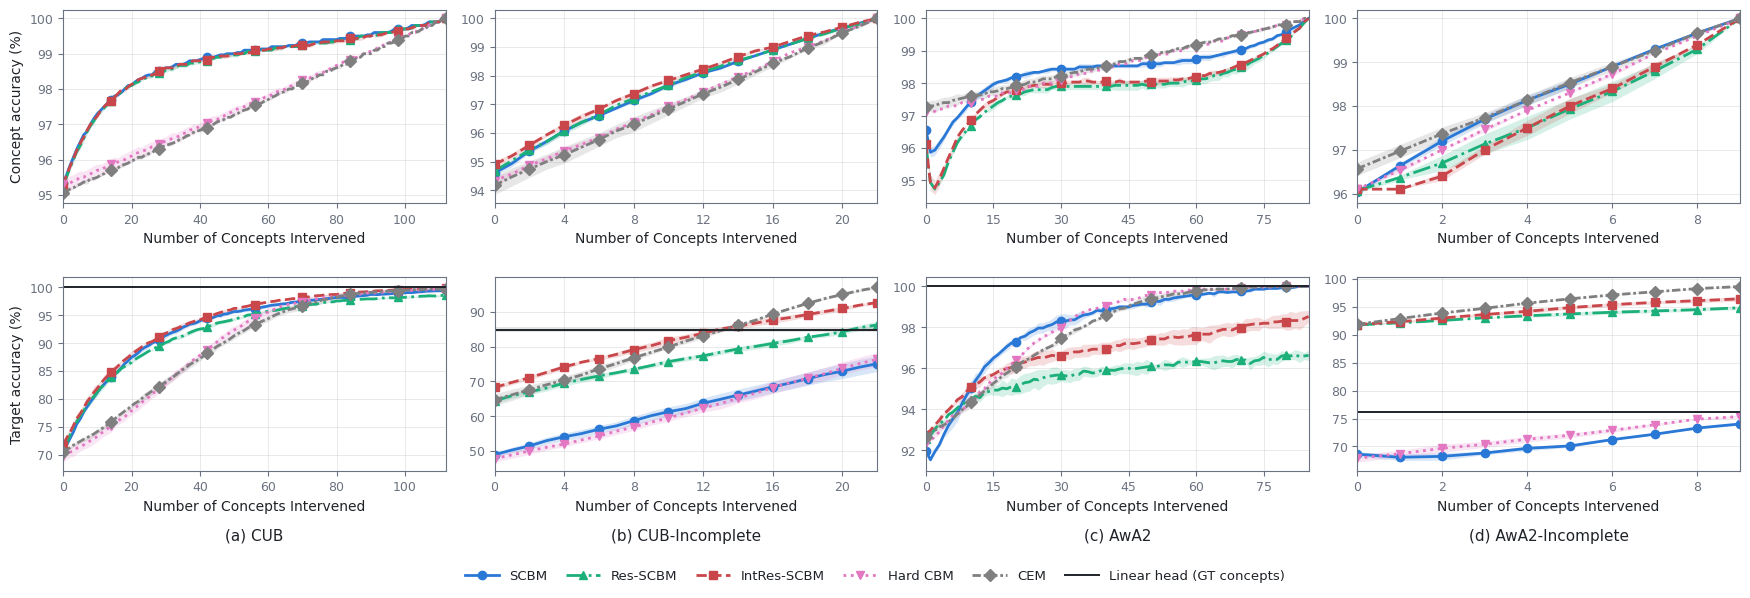

In [34]:
from matplotlib.ticker import MaxNLocator

# Type-42 (TrueType) fonts in the PDF instead of matplotlib's default Type 3, which
# several venues (IEEE, ACM) reject outright and which some viewers render poorly.
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# Combined CUB / CUB-Incomplete / AwA2 / AwA2-Incomplete intervention figure, in the
# layout of the SCBM paper's Figure: columns = dataset, rows = concept accuracy (top) /
# target accuracy (bottom), one shared legend underneath, no figure title (the LaTeX caption
# carries it). Reuses collect_model / read_run_config / parse_intervention_log /
# collect_linear_head / gt_band and CUB_MODELS / GT_GLOB from the intervention-curve cell
# above; AWA2_MODELS mirrors the spec list in final_incomplete_awa2.ipynb, so this one
# figure replaces both notebooks' single panels.
#
# c_accuracy is logged at every sweep point of intervention_log.txt, which is what makes
# the top row possible without re-running anything. The ground-truth linear head only has
# a target accuracy, so its flat reference line sits on the bottom row alone.

# Complete datasets. Complete and incomplete runs share experiments/<model_type>/<dataset>/,
# so the globs are anchored on the "complete_" prefix; the plain Res-SCBM glob cannot match
# the L_int runs, whose "_L_int_..." tag sits between "residuals_20_" and the date. Same
# training config as the incomplete runs apart from the split.
CUB_COMPLETE_MODELS = [
    ("SCBM",                 "scbm",          "complete_residuals_20_2026-*"),
    ("Res-SCBM",             "scbm_residual", "complete_residuals_20_2026-*"),
    ("IntRes-SCBM", "scbm_residual",
     "complete_residuals_20_L_int_extension_loss_weight_1_2026-*"),
    ("Hard CBM",             "cbm",           "hard_cbm_complete_2026-*"),
    ("CEM", "cbm",   "cem_p_int_0.25_complete_2026-*"),
]
AWA2_COMPLETE_MODELS = [
    ("SCBM",                 "scbm",          "complete_awa2_2026-*"),
    ("Res-SCBM",             "scbm_residual", "complete_awa2_emp_perc_residuals_20_2026-*"),
    ("IntRes-SCBM", "scbm_residual",
     "complete_awa2_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-*"),
    ("Hard CBM",             "cbm",           "hard_cbm_complete_awa2_2026-*"),
    ("CEM", "cbm",   "cem_p_int_0.25_complete_awa2_2026-*"),
]
AWA2_MODELS = [
    ("SCBM",                 "scbm",          "incomplete_awa2_2026-*"),
    ("Res-SCBM",             "scbm_residual", "incomplete_awa2_emp_perc_residuals_20_2026-*"),
    ("IntRes-SCBM", "scbm_residual",
     "incomplete_awa2_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-*"),
    ("Hard CBM",             "cbm",           "hard_cbm_incomplete_awa2_2026-*"),
    ("CEM", "cbm",   "cem_p_int_0.25_incomplete_awa2_2026-*"),
]

# CEM is gray here, not the purple of the single-panel cell above. Measured in OKLab, the
# purple sat at dE 14.5 from SCBM's blue for normal vision (below the 15 floor) and 8.6
# under protanopia - the one pair a reader most needs to separate, since CEM is the
# leakage comparison against the SCBM baseline. Gray clears both (15.8 / 8.2) and doubles
# as the "not a like-for-like comparison" signal, CEM being the only model trained on
# interventions. Every pair in this palette is now >= 15 normal / >= 8 CVD.
PANEL_COLORS = {
    "SCBM": "#2a78d6",
    "Res-SCBM": "#1baf7a",
    "IntRes-SCBM": "#c9464b",
    "Hard CBM": "#e377c2",
    "CEM": "#7f7f7f",
}
PANEL_MARKERS = {"SCBM": "o", "Res-SCBM": "^", "IntRes-SCBM": "s",
                 "Hard CBM": "v", "CEM": "D"}
PANEL_LINESTYLES = {"SCBM": "-", "Res-SCBM": "-.", "IntRes-SCBM": "--",
                    "Hard CBM": ":", "CEM": (0, (3, 1, 1, 1))}
# Marker + dash differ per model, so identity never rests on hue alone. The ground-truth
# line is near-black, marker-less and spans the full width, which separates it from CEM's gray.

# (panel label, experiments/ dataset folder, model specs, expected split, linear-head glob).
# The complete datasets have no linear-head glob (None): their reference is the fixed
# GT_COMPLETE_ACC = 100% line instead. Complete AwA2 runs log pkl_file_dir=None, which
# collect_model reports as "complete".
PANELS = [
    ("CUB",             "CUB",  CUB_COMPLETE_MODELS,  "class_attr_data_10", None),
    ("CUB-Incomplete",  "CUB",  CUB_MODELS,           "Mateo_025",          GT_GLOB),
    ("AwA2",            "AwA2", AWA2_COMPLETE_MODELS, "complete",           None),
    ("AwA2-Incomplete", "AwA2", AWA2_MODELS, "awa2_incomplete_local_custom_1",
     "awa2_incomplete_local_custom_1_2026-*_seed_*"),
]
# Complete datasets: the full class-level concept set identifies the class exactly, so a
# linear head on the ground-truth concepts is at 100% (the earlier seedless runs scored
# 1.0000 on both CUB and AwA2). Drawn as a fixed reference line, without a seed band.
GT_COMPLETE_ACC = 100.0
ROWS = [("c_accuracy", "Concept accuracy (%)"), ("y_accuracy", "Target accuracy (%)")]
INK, MUTED = "#1f2328", "#6b7280"


# curves[(panel, metric)] -> list of per-model dicts; gts[panel] -> linear-head dict.
# Keyed by panel label, not dataset folder: complete and incomplete runs share a folder.
curves, gts = {}, {}
for panel, dataset, specs, expected_split, gt_glob in PANELS:
    for metric, _ in ROWS:
        ms = [collect_model(*s, dataset=dataset, metric=metric) for s in specs]
        assert len({m["shape"] for m in ms}) == 1, f"{panel}: models differ in setup"
        assert all((m["x"] == ms[0]["x"]).all() for m in ms), f"{panel}: x grids differ"
        assert ms[0]["shape"][2] == expected_split, \
            f"{panel}: split is {ms[0]['shape'][2]}, expected {expected_split}"
        curves[(panel, metric)] = ms
    gts[panel] = ({"label": GT_LABEL, "seeds": [], "run_dirs": [], "y": np.array([GT_COMPLETE_ACC])}
                  if gt_glob is None else collect_linear_head(gt_glob, dataset, ms[0]["shape"]))

fig, axes = plt.subplots(2, len(PANELS), figsize=(4.4 * len(PANELS), 6.0))
for col, (panel, _, _, _, _) in enumerate(PANELS):
    n_classes, n_concepts, _ = curves[(panel, "y_accuracy")][0]["shape"]
    for row, (metric, ylabel) in enumerate(ROWS):
        ax = axes[row, col]
        for m in curves[(panel, metric)]:
            mean = m["y"].mean(axis=0)
            if BAND == "std":
                sd = m["y"].std(axis=0, ddof=1)
                lo, hi = mean - sd, mean + sd
            else:
                lo, hi = m["y"].min(axis=0), m["y"].max(axis=0)
            color = PANEL_COLORS[m["label"]]
            ax.fill_between(m["x"], lo, hi, color=color, alpha=0.18, linewidth=0)
            ax.plot(m["x"], mean, marker=PANEL_MARKERS[m["label"]], ms=6, lw=2.0,
                    markevery=max(1, len(m["x"]) // 8), linestyle=PANEL_LINESTYLES[m["label"]],
                    color=color, label=m["label"])
        if metric == "y_accuracy":
            gt_mean, gt_lo, gt_hi = gt_band(gts[panel])
            ax.axhspan(gt_lo, gt_hi, color=INK, alpha=0.12, linewidth=0)
            ax.axhline(gt_mean, color=INK, lw=1.4, label=GT_LABEL)
        ax.set_xlabel("Number of Concepts Intervened", fontsize=10, color=INK)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=10, color=INK)
        ax.set_xlim(0, n_concepts)
        # Concepts are counted, not measured: no 2.5-concept tick.
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=7))
        ax.grid(True, alpha=0.3, linewidth=0.6)
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=9, colors=MUTED)
        # Full box frame on every panel, as in the SCBM paper's figure.
        for side in ("top", "right", "left", "bottom"):
            ax.spines[side].set_visible(True)
            ax.spines[side].set_color(MUTED)
            ax.spines[side].set_linewidth(0.8)
    # Panel caption under the bottom axes of this column, as in the paper's (a)/(b)/...
    axes[1, col].set_title(f"({'abcdefgh'[col]}) {panel}",
                           fontsize=11, color=INK, y=-0.40)

# Legend from a target-accuracy panel: only that row carries the ground-truth line.
handles, labels = axes[1, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(handles), frameon=False,
           fontsize=9.5, bbox_to_anchor=(0.5, 0.0), handlelength=2.6,
           labelcolor=INK, columnspacing=1.4)
# No figure title: the caption in the paper carries it.
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.subplots_adjust(hspace=0.38)

# PDF for the paper (vector, no resampling at any zoom) plus a PNG for slides and
# quick viewing. Same figure, same bounding box.
OUT_DIR = "plots_paper"
os.makedirs(OUT_DIR, exist_ok=True)
stem = os.path.join(OUT_DIR, "intervention_curves_cub_awa2_complete_incomplete")
for ext in ("pdf", "png"):
    fig.savefig(f"{stem}.{ext}", dpi=200, bbox_inches="tight", facecolor="white")
    print("saved", f"{stem}.{ext}")
plt.show()

### Combined summary table

Test-set concept and target accuracy for CUB, CUB-Incomplete, AwA2 and AwA2-Incomplete
side by side, mean ± std over the 3 seeds — the tabular companion to the figure above,
replacing the separate per-dataset tables in this notebook and in
`final_incomplete_awa2.ipynb`. The linear-head cells for the complete datasets are the fixed
100% reference (see the figure's note), so they carry no "± std".

Depends on `collect_test_metrics` / `TABLE_ORDER` / `TABLE_NAMES` / `METRICS` from the
**Test accuracy table** cell and on `PANELS` / `gts` from the figure cell above.

In [35]:
# Combined CUB / CUB-Incomplete / AwA2 / AwA2-Incomplete test-set summary table: concept
# and target accuracy, mean +/- std over the 3 seeds, datasets side by side. The tabular
# companion to the combined figure, and it replaces the separate per-dataset tables in this
# notebook and in final_incomplete_awa2.ipynb.
#
# Source is the single "Test:" line of each run's log.txt (best-validation checkpoint on
# the test split), NOT the 0-intervention row of intervention_log.txt -- the two differ by
# a few tenths because the sweep re-samples the concept logits. Reuses collect_test_metrics
# / parse_test_line / TABLE_ORDER / TABLE_NAMES / METRICS from the test-accuracy cell and
# PANELS / gts from the combined-figure cell, so the columns match the figure's panels. The
# ground-truth linear head is a separate reference row: no concept accuracy ("—"), excluded
# from the best / runner-up marking. On the complete datasets it is the fixed 100% reference
# (GT_COMPLETE_ACC), printed without "± std".

SUMMARY_DATASETS = [(panel, dataset, specs) for panel, dataset, specs, _, _ in PANELS]

# summary[(dataset label, model label)] -> {metric: per-seed array}
# ds_label, not `display`: that name is Jupyter's own and shadowing it breaks the table.
summary = {}
for ds_label, dataset, specs in SUMMARY_DATASETS:
    by_label = {label: (label, mt, g) for label, mt, g in specs}
    for label in TABLE_ORDER:
        summary[(ds_label, label)] = collect_test_metrics(*by_label[label], dataset=dataset)


def gt_cell(ds_label, metric, pm, dash):
    """Linear-head reference cell: target accuracy, with "± std" only if it has seeds."""
    g = gts[ds_label]
    if metric != "y_accuracy":
        return dash
    if len(g["y"]) == 1:
        return f"{g['y'][0]:.2f}"
    return f"{g['y'].mean():.2f}{pm}{g['y'].std(ddof=1):.2f}"


columns = pd.MultiIndex.from_tuples(
    [(ds_label, col) for ds_label, _, _ in SUMMARY_DATASETS for _, col in METRICS])
summary_table = pd.DataFrame(
    [[f"{summary[(ds_label, label)][m].mean():.2f} ± {summary[(ds_label, label)][m].std(ddof=1):.2f}"
      for ds_label, _, _ in SUMMARY_DATASETS for m, _ in METRICS]
     for label in TABLE_ORDER],
    index=[TABLE_NAMES.get(l, l) for l in TABLE_ORDER], columns=columns)
summary_table.loc[GT_LABEL] = [gt_cell(ds_label, m, " ± ", "—")
                               for ds_label, _, _ in SUMMARY_DATASETS for m, _ in METRICS]
summary_table.index.name = "Method"
print("Test split, mean ± std over seeds [0, 10, 20]")
display(summary_table)

# LaTeX: best per column in bold, runner-up underlined, grouped header per dataset.
means = np.array([[summary[(ds_label, label)][m].mean()
                   for ds_label, _, _ in SUMMARY_DATASETS for m, _ in METRICS]
                  for label in TABLE_ORDER])
stds = np.array([[summary[(ds_label, label)][m].std(ddof=1)
                  for ds_label, _, _ in SUMMARY_DATASETS for m, _ in METRICS]
                 for label in TABLE_ORDER])
rank = (-means).argsort(axis=0)  # descending down each column; higher accuracy is better

latex_rows = []
for i, label in enumerate(TABLE_ORDER):
    cells = []
    for j in range(means.shape[1]):
        cell = f"{means[i, j]:.2f} $\\pm$ {stds[i, j]:.2f}"
        if i == rank[0, j]:
            cell = f"\\textbf{{{cell}}}"
        elif i == rank[1, j]:
            cell = f"\\underline{{{cell}}}"
        cells.append(cell)
    latex_rows.append(f"{TABLE_NAMES.get(label, label)} & " + " & ".join(cells) + r" \\")
gt_cells = [gt_cell(ds_label, m, " $\\pm$ ", "--")
            for ds_label, _, _ in SUMMARY_DATASETS for m, _ in METRICS]

n_metrics = len(METRICS)
print("\n% CUB (complete / Mateo_025) and AwA2 (complete / awa2_incomplete_local_custom_1),")
print("% test split, mean $\\pm$ std over 3 seeds")
print(r"\begin{tabular}{l" + "c" * means.shape[1] + "}")
print(r"\toprule")
print("& " + " & ".join(f"\\multicolumn{{{n_metrics}}}{{c}}{{{d}}}"
                        for d, _, _ in SUMMARY_DATASETS) + r" \\")
print(" ".join(f"\\cmidrule(lr){{{2 + k * n_metrics}-{1 + (k + 1) * n_metrics}}}"
               for k in range(len(SUMMARY_DATASETS))))
print("Method & " + " & ".join(col for _, _, _ in SUMMARY_DATASETS for _, col in METRICS) + r" \\")
print(r"\midrule")
print("\n".join(latex_rows))
print(r"\midrule")
print(f"{GT_LABEL} & " + " & ".join(gt_cells) + r" \\")
print(r"\bottomrule")
print(r"\end{tabular}")

Test split, mean ± std over seeds [0, 10, 20]


CUB                   CUB-Incomplete  \
                          Concept Accuracy Target Accuracy Concept Accuracy   
Method                                                                        
Hard CBM                      95.30 ± 0.17    69.63 ± 0.90     94.33 ± 0.15   
CEM                           95.07 ± 0.06    70.50 ± 0.36     94.17 ± 0.32   
SCBM                          95.37 ± 0.06    71.30 ± 0.00     94.57 ± 0.06   
Res-SCBM                      95.23 ± 0.06    70.87 ± 0.15     94.67 ± 0.12   
IntRes-SCBM                   95.23 ± 0.06    71.80 ± 0.70     94.90 ± 0.10   
Linear head (GT concepts)                —          100.00                —   

                                                      AwA2                  \
                          Target Accuracy Concept Accuracy Target Accuracy   
Method                                                                       
Hard CBM                     47.87 ± 1.00     97.10 ± 0.00    92.30 ± 0.10   
CEM                          64.77 ± 1.71     97.27 ± 0.15    92.63 ± 0.25   
SCBM                         49.03 ± 0.71     96.57 ± 0.06    91.87 ± 0.15   
Res-SCBM                     64.43 ± 0.72     96.17 ± 0.06    92.60 ± 0.17   
IntRes-SCBM                  68.20 ± 0.69     96.13 ± 0.15    92.77 ± 0.06   
Linear head (GT concepts)    84.91 ± 0.72                —          100.00   

                           AwA2-Incomplete                  
                          Concept Accuracy Target Accuracy  
Method                                                      
Hard CBM                      96.10 ± 0.00    68.20 ± 0.87  
CEM                           96.57 ± 0.15    91.87 ± 0.06  
SCBM                          96.03 ± 0.06    68.43 ± 0.31  
Res-SCBM                      96.07 ± 0.06    91.87 ± 0.06  
IntRes-SCBM                   96.10 ± 0.00    91.77 ± 0.12  
Linear head (GT concepts)                —    76.20 ± 0.03


% CUB (complete / Mateo_025) and AwA2 (complete / awa2_incomplete_local_custom_1),
% test split, mean $\pm$ std over 3 seeds
\begin{tabular}{lcccccccc}
\toprule
& \multicolumn{2}{c}{CUB} & \multicolumn{2}{c}{CUB-Incomplete} & \multicolumn{2}{c}{AwA2} & \multicolumn{2}{c}{AwA2-Incomplete} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
Method & Concept Accuracy & Target Accuracy & Concept Accuracy & Target Accuracy & Concept Accuracy & Target Accuracy & Concept Accuracy & Target Accuracy \\
\midrule
Hard CBM & \underline{95.30 $\pm$ 0.17} & 69.63 $\pm$ 0.90 & 94.33 $\pm$ 0.15 & 47.87 $\pm$ 1.00 & \underline{97.10 $\pm$ 0.00} & 92.30 $\pm$ 0.10 & \underline{96.10 $\pm$ 0.00} & 68.20 $\pm$ 0.87 \\
CEM & 95.07 $\pm$ 0.06 & 70.50 $\pm$ 0.36 & 94.17 $\pm$ 0.32 & \underline{64.77 $\pm$ 1.71} & \textbf{97.27 $\pm$ 0.15} & \underline{92.63 $\pm$ 0.25} & \textbf{96.57 $\pm$ 0.15} & \textbf{91.87 $\pm$ 0.06} \\
SCBM & \textbf{95.37 $\pm$ 0.06} & \underline{71.30 $\

## Group-wise interventions on the complete datasets

The combined figure intervenes on one random concept per sample and step
(`intervention_log.txt`, policy `random`). This section adds the group-wise sweep of the
same checkpoints (`intervention_log_random_group.txt`, from
`inference.py ... inference.inter_policy=random_group`): every step reveals one complete
semantic concept group — AwA2's 28 CEM groups, CUB's 28 `ATTRIBUTE_PARTS` — so its x-axis
counts groups. The group is drawn per *batch* rather than per sample, because the SCBM
strategies need every sample of a batch to carry the same number of intervened concepts;
the curve therefore averages over batches. Each log line also records the mean number of
concepts the step amounts to, which the printed table reports.

One figure per complete dataset, in the layout of the combined figure (rows: concept and
target accuracy, 100% ground-truth reference, ± std over the 3 seeds), saved to
`plots_paper/intervention_curves_<dataset>_complete_groupwise.{pdf,png}`. A dataset whose
runs have no group-wise log yet is skipped with a note, so CUB appears here as soon as its
logs are synced. Depends on `curves`, `AWA2_COMPLETE_MODELS` / `CUB_COMPLETE_MODELS`, the
`PANEL_*` styles and `OUT_DIR` from the **Combined CUB + AwA2 figure** cell — run that first.



AwA2: 50 classes, 85 concepts, 28 groups, seeds [0, 10, 20]
model          |  concept-wise  0            ~42             85 |  group-wise  0             14             28
SCBM           |     91.97 ± 0.06   98.93 ± 0.15  100.00 ± 0.00 |   91.93 ± 0.12   98.83 ± 0.12  100.00 ± 0.00
Res-SCBM       |     92.53 ± 0.06   95.90 ± 0.26   96.63 ± 0.25 |   92.57 ± 0.06   95.77 ± 0.15   96.70 ± 0.26
IntRes-SCBM    |     92.77 ± 0.15   97.13 ± 0.25   98.53 ± 0.29 |   92.70 ± 0.10   97.03 ± 0.35   98.43 ± 0.29
Hard CBM       |     92.33 ± 0.12   99.20 ± 0.00  100.00 ± 0.00 |   92.33 ± 0.12   98.97 ± 0.06  100.00 ± 0.00
CEM            |     92.63 ± 0.25   98.80 ± 0.10  100.00 ± 0.00 |   92.63 ± 0.25   98.67 ± 0.15  100.00 ± 0.00
saved plots_paper/intervention_curves_awa2_complete_groupwise.pdf
saved plots_paper/intervention_curves_awa2_complete_groupwise.png


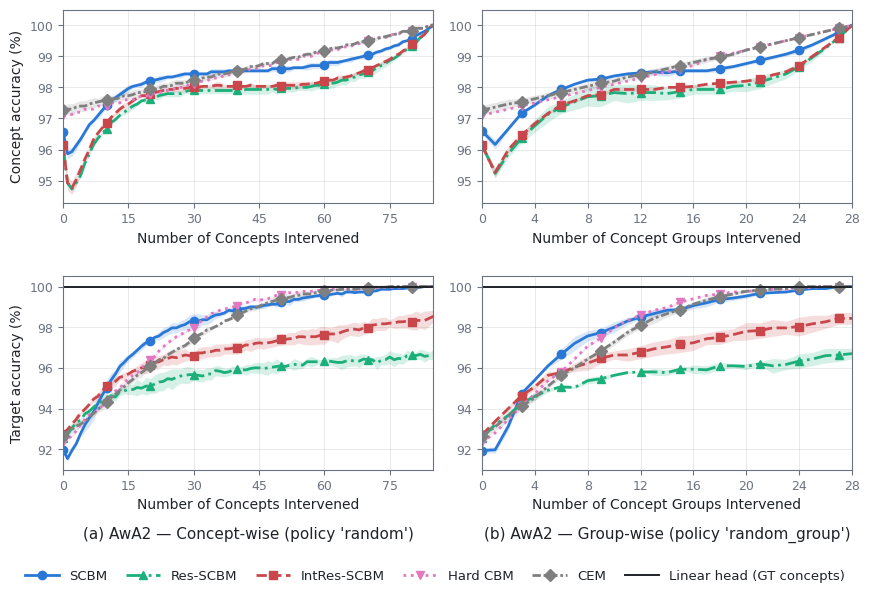

CUB: no intervention_log_random_group.txt yet for ['SCBM', 'Res-SCBM', 'IntRes-SCBM', 'Hard CBM', 'CEM'] - skipped


In [36]:
from matplotlib.lines import Line2D

# Group-wise interventions (inference.inter_policy=random_group) next to the concept-wise
# curves (policy 'random') of the combined figure above, on the complete datasets. Every
# step of the group-wise sweep adds one complete semantic concept group (CUB: the 28
# ATTRIBUTE_PARTS, AwA2: the 28 CEM groups) instead of one concept, so its x-axis counts
# groups. Each log line also records the mean number of concepts the step amounts to (kept
# in `mean_concepts`, printed in the table). The group is drawn per batch
# (the SCBM strategies need every sample of a batch to have the same number of intervened
# concepts), so the curve averages over batches rather than samples.
#
# Reuses collect_model's output (`curves`, keyed by panel label), AWA2_COMPLETE_MODELS /
# CUB_COMPLETE_MODELS, PANEL_COLORS / PANEL_MARKERS / PANEL_LINESTYLES, ROWS, BAND,
# EXPECTED_SEEDS, GT_COMPLETE_ACC and OUT_DIR from the combined-figure cell above. A dataset
# whose runs have no group-wise log yet is skipped with a note, so CUB appears here as soon
# as its intervention_log_random_group.txt files are synced.

GROUP_LOG = "intervention_log_random_group.txt"
_GROUP_STEP_RE = re.compile(r"Intervention on (\d+) groups(?: \(mean ([0-9.]+) concepts\))?: ")


def parse_group_intervention_log(log_txt_path):
    """Return (xs, mean_concepts, rows) for the group-wise log.

    xs[i] groups intervened, mean_concepts[i] the mean number of concepts that amounts to
    (0 at step 0, where the log has no "(mean ...)" clause), rows[i] the {metric: value}
    dict. Keyed by step, so a partial sweep followed by a re-run keeps the last value.
    """
    curve = {}
    with open(log_txt_path, "r") as f:
        for line in f:
            m = _GROUP_STEP_RE.match(line)
            if not m or "y_accuracy" not in line:
                continue
            step = int(m.group(1))
            mean_c = float(m.group(2)) if m.group(2) is not None else 0.0
            metrics = {k: float(v) for k, v in
                       re.findall(r"([A-Za-z_\-]+):\s*([0-9.]+)", line[m.end():])}
            curve[step] = (mean_c, metrics)
    xs = sorted(curve)
    return xs, [curve[x][0] for x in xs], [curve[x][1] for x in xs]


def collect_model_groups(label, model_type, run_glob, dataset, metric="y_accuracy"):
    """collect_model for the group-wise log; None while no seed of the model has it yet."""
    run_paths = sorted(glob.glob(os.path.join("experiments", model_type, dataset, run_glob)))
    seeds, curves_, mean_cs, run_dirs, xs_ref, shapes = [], [], [], [], None, set()
    for run_path in run_paths:
        log_txt = os.path.join(run_path, GROUP_LOG)
        if not os.path.exists(log_txt):
            continue
        cfg = read_run_config(run_path)
        xs, mean_c, rows = parse_group_intervention_log(log_txt)
        if xs_ref is None:
            xs_ref = xs
        assert xs == xs_ref, f"{run_path}: group grid differs from the other seeds"
        shapes.add((cfg["data"]["num_classes"], cfg["data"]["num_concepts"],
                    (cfg["data"]["pkl_file_dir"] or "complete").rstrip("/")))
        seeds.append(cfg["seed"])
        curves_.append([r[metric] * 100 for r in rows])
        mean_cs.append(mean_c)
        run_dirs.append(os.path.basename(run_path))
    if not seeds:
        return None
    assert set(seeds) == EXPECTED_SEEDS, \
        f"{label} ({dataset}/{run_glob}): {GROUP_LOG} found for seeds {sorted(seeds)}, expected {sorted(EXPECTED_SEEDS)}"
    assert len(shapes) == 1, f"{label}: seeds disagree on classes/concepts/split: {shapes}"
    return {"label": label, "model_type": model_type, "seeds": sorted(seeds),
            "run_dirs": run_dirs, "shape": shapes.pop(), "x": np.array(xs_ref),
            "mean_concepts": np.array(mean_cs).mean(axis=0), "y": np.array(curves_)}


def band(y):
    """(mean, lo, hi) over seeds, same BAND rule as the figures above."""
    mean = y.mean(axis=0)
    if BAND == "std":
        sd = y.std(axis=0, ddof=1)
        return mean, mean - sd, mean + sd
    return mean, y.min(axis=0), y.max(axis=0)


# (panel label as in PANELS, experiments/ dataset folder, model specs).
GROUP_PANELS = [
    ("AwA2", "AwA2", AWA2_COMPLETE_MODELS),
    ("CUB",  "CUB",  CUB_COMPLETE_MODELS),
]
COLS = [("concepts", "Concept-wise (policy 'random')"),
        ("groups", "Group-wise (policy 'random_group')")]

for panel, dataset, specs in GROUP_PANELS:
    gcurves = {}
    for metric, _ in ROWS:
        ms = [collect_model_groups(*s, dataset=dataset, metric=metric) for s in specs]
        missing = [s[0] for s, m in zip(specs, ms) if m is None]
        if missing:
            print(f"{panel}: no {GROUP_LOG} yet for {missing} - skipped")
            break
        assert len({m["shape"] for m in ms}) == 1, f"{panel}: models differ in setup"
        assert all((m["x"] == ms[0]["x"]).all() for m in ms), f"{panel}: group grids differ"
        assert ms[0]["shape"] == curves[(panel, metric)][0]["shape"], \
            f"{panel}: group-wise runs are not the concept-wise runs' setup"
        gcurves[metric] = ms
    else:
        n_classes, n_concepts, _ = gcurves["y_accuracy"][0]["shape"]
        n_groups = int(gcurves["y_accuracy"][0]["x"].max())

        # Target accuracy at no / half / full intervention, both policies, mean +/- std.
        print(f"\n{panel}: {n_classes} classes, {n_concepts} concepts, {n_groups} groups, "
              f"seeds {gcurves['y_accuracy'][0]['seeds']}")
        print(f"{'model':<14} | {'concept-wise  0':>16} {'~' + str(n_concepts // 2):>14} {n_concepts:>14} "
              f"| {'group-wise  0':>14} {n_groups // 2:>14} {n_groups:>14}")
        for cm, gm in zip(curves[(panel, "y_accuracy")], gcurves["y_accuracy"]):
            cells = []
            for m, pts in ((cm, (0, n_concepts // 2, n_concepts)), (gm, (0, n_groups // 2, n_groups))):
                for p in pts:
                    i = int(np.argmin(np.abs(m["x"] - p)))
                    cells.append(f"{m['y'][:, i].mean():.2f} ± {m['y'][:, i].std(ddof=1):.2f}")
            print(f"{cm['label']:<14} | {cells[0]:>16} {cells[1]:>14} {cells[2]:>14} "
                  f"| {cells[3]:>14} {cells[4]:>14} {cells[5]:>14}")

        fig, axes = plt.subplots(len(ROWS), len(COLS), figsize=(4.4 * len(COLS), 6.0))
        for row, (metric, ylabel) in enumerate(ROWS):
            for col, (kind, _) in enumerate(COLS):
                ax = axes[row, col]
                for cm, gm in zip(curves[(panel, metric)], gcurves[metric]):
                    color = PANEL_COLORS[cm["label"]]
                    style = dict(color=color, linestyle=PANEL_LINESTYLES[cm["label"]],
                                 marker=PANEL_MARKERS[cm["label"]], label=cm["label"])
                    if kind == "concepts":
                        mean, lo, hi = band(cm["y"])
                        ax.fill_between(cm["x"], lo, hi, color=color, alpha=0.18, linewidth=0)
                        ax.plot(cm["x"], mean, ms=6, lw=2.0,
                                markevery=max(1, len(cm["x"]) // 8), **style)
                    else:
                        mean, lo, hi = band(gm["y"])
                        ax.fill_between(gm["x"], lo, hi, color=color, alpha=0.18, linewidth=0)
                        ax.plot(gm["x"], mean, ms=6, lw=2.0,
                                markevery=max(1, len(gm["x"]) // 8), **style)
                if metric == "y_accuracy":
                    ax.axhline(GT_COMPLETE_ACC, color=INK, lw=1.4, label=GT_LABEL)
                if kind == "groups":
                    ax.set_xlabel("Number of Concept Groups Intervened", fontsize=10, color=INK)
                    ax.set_xlim(0, n_groups)
                else:
                    ax.set_xlabel("Number of Concepts Intervened", fontsize=10, color=INK)
                    ax.set_xlim(0, n_concepts)
                if col == 0:
                    ax.set_ylabel(ylabel, fontsize=10, color=INK)
                ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=7))
                ax.grid(True, alpha=0.3, linewidth=0.6)
                ax.set_axisbelow(True)
                ax.tick_params(labelsize=9, colors=MUTED)
                for side in ("top", "right", "left", "bottom"):
                    ax.spines[side].set_visible(True)
                    ax.spines[side].set_color(MUTED)
                    ax.spines[side].set_linewidth(0.8)
        # Same y-limits across the row, so the two columns can be read against each other.
        for row in range(len(ROWS)):
            lo = min(ax.get_ylim()[0] for ax in axes[row])
            for ax in axes[row]:
                ax.set_ylim(lo, 100.5)
        for col, (_, title) in enumerate(COLS):
            axes[1, col].set_title(f"({'ab'[col]}) {panel} — {title}", fontsize=11, color=INK, y=-0.40)

        handles, labels = axes[1, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=len(handles), frameon=False, fontsize=9.5,
                   bbox_to_anchor=(0.5, 0.0), handlelength=2.6, labelcolor=INK, columnspacing=1.4)
        fig.tight_layout(rect=(0, 0.05, 1, 1))
        fig.subplots_adjust(hspace=0.38)

        stem = os.path.join(OUT_DIR, f"intervention_curves_{dataset.lower()}_complete_groupwise")
        for ext in ("pdf", "png"):
            fig.savefig(f"{stem}.{ext}", dpi=200, bbox_inches="tight", facecolor="white")
            print("saved", f"{stem}.{ext}")
        plt.show()


## Validation curves, complete AwA2

Per-epoch validation metrics of the complete AwA2 runs, read from the `Epoch <n>, Validation:`
lines of each run's `log.txt` (epoch 0 is the untrained model). One thin line per seed; the
marker sits on the epoch early stopping selected — the first maximum of validation target
accuracy (`maybe_save_best_model` in `train.py`) — which is the checkpoint behind every test
number and intervention curve above. Budget 200 epochs, patience 30, so runs end at
different epochs. Losses are on a log axis; the accuracy panels start above the epoch-0
chance level. The printed table gives, per seed, the last epoch reached, the selected
epoch, the validation accuracies there and the test target accuracy.

Depends on `AWA2_COMPLETE_MODELS`, the `PANEL_*` styles and `OUT_DIR` from the
**Combined CUB + AwA2 figure** cell and on `read_run_config` / `EXPECTED_SEEDS` from the
**Intervention curves** cell. Saves to `plots_paper/validation_curves_awa2_complete.{pdf,png}`.


model          seed  last ep  best ep  best val y_acc  val c_acc @best  test y_acc
SCBM              0      199      157           92.20            96.40       91.70
SCBM             10      184      150           92.20            96.40       92.00
SCBM             20      199      161           92.30            96.40       91.90
Res-SCBM          0      154      124           93.10            96.10       92.80
Res-SCBM         10      134      104           93.00            96.00       92.50
Res-SCBM         20      145      115           92.80            96.00       92.50
IntRes-SCBM       0      128       98           93.00            95.90       92.80
IntRes-SCBM      10      147      117           93.00            96.00       92.70
IntRes-SCBM      20      156      126           92.80            96.10       92.80
Hard CBM          0      146       99           92.30            97.00       92.30
Hard CBM         10      149      113           92.30            97.00       92.40
Hard

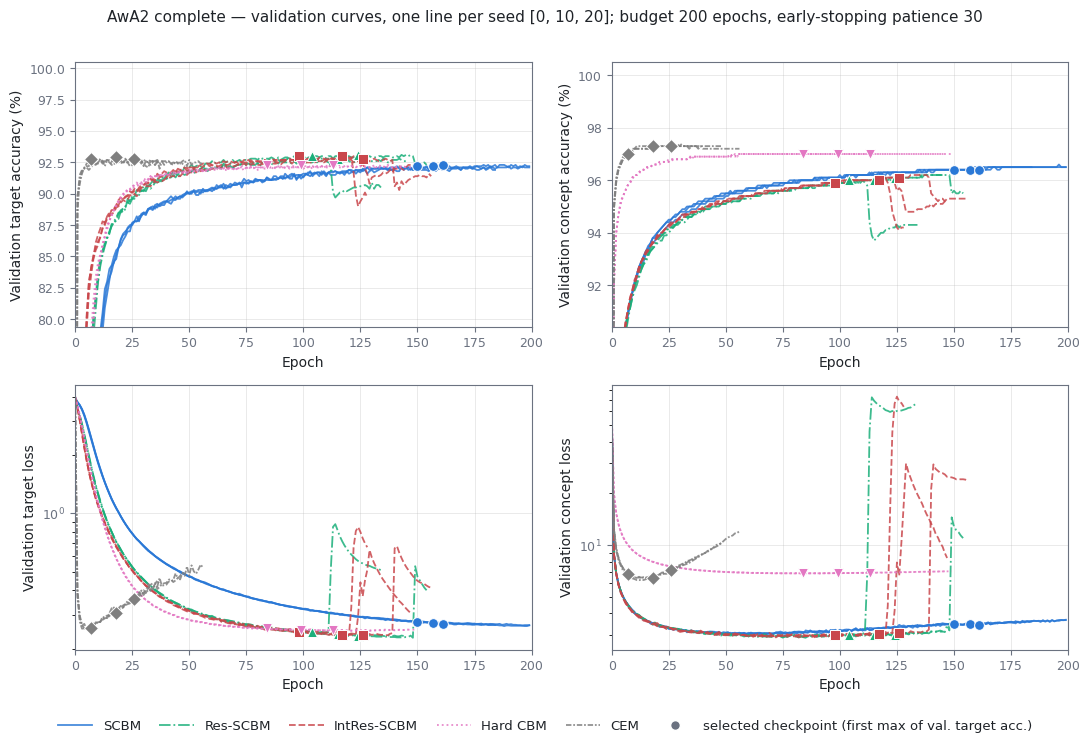

In [37]:
# Validation curves of the complete AwA2 runs: the per-epoch "Epoch <n>, Validation:" lines
# of each run's log.txt (epoch 0 is the untrained model). One thin line per seed in the
# model's colour; the marker sits on the epoch early stopping selected, i.e. the first
# maximum of validation target accuracy (maybe_save_best_model in train.py), which is the
# checkpoint every test number and intervention curve above was measured on. Runs end at
# different epochs: j_epochs=200 with early_stopping_patience=30.
# Reuses AWA2_COMPLETE_MODELS, PANEL_COLORS / PANEL_MARKERS / PANEL_LINESTYLES, INK, MUTED,
# OUT_DIR (combined-figure cell) and read_run_config / EXPECTED_SEEDS (intervention-curve cell).

_EPOCH_RE = re.compile(r"^Epoch (\d+), (Validation|Train)\s*: ")


def parse_epoch_log(run_path, split="Validation"):
    """(epochs, rows) of the per-epoch `split` lines of log.txt; rows[i] = {metric: value}."""
    curve = {}
    with open(os.path.join(run_path, "log.txt"), "r") as f:
        for line in f:
            m = _EPOCH_RE.match(line)
            if not m or m.group(2) != split:
                continue
            curve[int(m.group(1))] = {k: float(v) for k, v in
                                      re.findall(r"([A-Za-z_\-]+):\s*([0-9.]+)", line[m.end():])}
    epochs = sorted(curve)
    return np.array(epochs), [curve[e] for e in epochs]


def collect_validation_curves(label, model_type, run_glob, dataset="AwA2"):
    """Per-seed validation curves of one model, sorted by seed."""
    runs = []
    for run_path in sorted(glob.glob(os.path.join("experiments", model_type, dataset, run_glob))):
        cfg = read_run_config(run_path)
        epochs, rows = parse_epoch_log(run_path, "Validation")
        val = {k: np.array([r[k] for r in rows]) for k in rows[0]}
        best = int(np.argmax(val["y_accuracy"]))  # first max = the checkpoint that was kept
        test_line = [l for l in open(os.path.join(run_path, "log.txt")) if l.startswith("Test:")]
        test = ({k: float(v) for k, v in re.findall(r"([A-Za-z_\-]+):\s*([0-9.]+)", test_line[0])}
                if test_line else {})
        runs.append({"seed": cfg["seed"], "run_dir": os.path.basename(run_path), "epochs": epochs,
                     "val": val, "best": best, "test": test,
                     "budget": cfg["model"]["j_epochs"], "patience": cfg["model"]["early_stopping_patience"]})
    runs.sort(key=lambda r: r["seed"])
    assert {r["seed"] for r in runs} == EXPECTED_SEEDS, \
        f"{label} ({dataset}/{run_glob}): found seeds {[r['seed'] for r in runs]}, expected {sorted(EXPECTED_SEEDS)}"
    return {"label": label, "runs": runs}


VAL_DATASET = "AwA2"
val_models = [collect_validation_curves(*s, dataset=VAL_DATASET) for s in AWA2_COMPLETE_MODELS]

# Where each run stopped and what it selected. "last epoch" < budget-1 means early stopping fired.
print(f"{'model':<14} {'seed':>4} {'last ep':>8} {'best ep':>8} {'best val y_acc':>15} {'val c_acc @best':>16} {'test y_acc':>11}")
for vm in val_models:
    for r in vm["runs"]:
        b = r["best"]
        print(f"{vm['label']:<14} {r['seed']:>4} {int(r['epochs'][-1]):>8} {int(r['epochs'][b]):>8} "
              f"{r['val']['y_accuracy'][b] * 100:>15.2f} {r['val']['c_accuracy'][b] * 100:>16.2f} "
              f"{r['test'].get('y_accuracy', float('nan')) * 100:>11.2f}")
budget, patience = val_models[0]["runs"][0]["budget"], val_models[0]["runs"][0]["patience"]

VAL_PANELS = [  # (metric, y label, scale, in %)
    ("y_accuracy",    "Validation target accuracy (%)",  "linear", True),
    ("c_accuracy",    "Validation concept accuracy (%)", "linear", True),
    ("target_loss",   "Validation target loss",          "log",    False),
    ("concepts_loss", "Validation concept loss",         "log",    False),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
for ax, (metric, ylabel, scale, pct) in zip(axes.ravel(), VAL_PANELS):
    for vm in val_models:
        color = PANEL_COLORS[vm["label"]]
        for i, r in enumerate(vm["runs"]):
            y = r["val"][metric] * (100 if pct else 1)
            ax.plot(r["epochs"], y, color=color, lw=1.3, alpha=0.85,
                    linestyle=PANEL_LINESTYLES[vm["label"]], label=vm["label"] if i == 0 else None)
            ax.plot(r["epochs"][r["best"]], y[r["best"]], color=color, marker=PANEL_MARKERS[vm["label"]],
                    ms=7, lw=0, markeredgecolor="white", markeredgewidth=0.7, zorder=5)
    ax.set_yscale(scale)
    ax.set_xlabel("Epoch", fontsize=10, color=INK)
    ax.set_ylabel(ylabel, fontsize=10, color=INK)
    ax.set_xlim(0, budget)
    ax.grid(True, alpha=0.3, linewidth=0.6, which="major")
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=9, colors=MUTED)
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(MUTED)
        ax.spines[side].set_linewidth(0.8)
# Accuracy panels: the interesting range is the top; the epoch-0 value (~chance) would flatten it.
for ax, (metric, _, _, _) in zip(axes.ravel(), VAL_PANELS):
    if metric in ("y_accuracy", "c_accuracy"):
        vals = np.concatenate([r["val"][metric][1:] * 100 for vm in val_models for r in vm["runs"]])
        ax.set_ylim(max(0, np.percentile(vals, 5) - 2), 100.5)

handles, labels = axes[0, 0].get_legend_handles_labels()
handles.append(Line2D([], [], color=MUTED, lw=0, marker="o", ms=7, markeredgecolor="white"))
labels.append("selected checkpoint (first max of val. target acc.)")
fig.legend(handles, labels, loc="lower center", ncol=len(handles), frameon=False, fontsize=9.5,
           bbox_to_anchor=(0.5, 0.0), handlelength=2.6, labelcolor=INK, columnspacing=1.4)
fig.suptitle(f"{VAL_DATASET} complete — validation curves, one line per seed {sorted(EXPECTED_SEEDS)}; "
             f"budget {budget} epochs, early-stopping patience {patience}", fontsize=11, color=INK)
fig.tight_layout(rect=(0, 0.05, 1, 0.97))

stem = os.path.join(OUT_DIR, f"validation_curves_{VAL_DATASET.lower()}_complete")
for ext in ("pdf", "png"):
    fig.savefig(f"{stem}.{ext}", dpi=200, bbox_inches="tight", facecolor="white")
    print("saved", f"{stem}.{ext}")
plt.show()


## Noisy Interventions

In [ ]:
# Intervention curves of the same models on a *corrupted* test set. inference.py with
# inference.noise.type=gaussian writes intervention_log_noise_gaussian_<std>.txt next to the
# clean intervention_log.txt of each run: nothing is retrained, the intervention strategy is
# still fitted on the clean train split, and the noise is applied in [0, 1] pixel space before
# the ImageNet normalisation, deterministic per sample (datasets/noise.py). One panel per
# condition with the colours / styles of the clean figure above, so the figure is read across
# panels: how much of the accuracy the noise removed does intervening give back, per model?
# Every noise level with at least one log is drawn; seeds missing a log are reported, not
# asserted, since the noisy sweeps are run per checkpoint.
NOISE_TYPE = "gaussian"


def noise_log_amounts(models=CUB_MODELS, noise_type=NOISE_TYPE, dataset="CUB"):
    """Noise levels for which at least one of the runs has a concept-wise log, ascending."""
    amounts = set()
    for _, model_type, run_glob in models:
        pattern = os.path.join("experiments", model_type, dataset, run_glob,
                               f"intervention_log_noise_{noise_type}_*.txt")
        for path in glob.glob(pattern):
            # "<amount>.txt" only: the group-wise logs end in "_random_group.txt".
            m = re.search(rf"_noise_{noise_type}_([0-9.]+)\.txt$", os.path.basename(path))
            if m:
                amounts.add(float(m.group(1)))
    return sorted(amounts)


def collect_model_log(label, model_type, run_glob, log_name, dataset="CUB", metric="y_accuracy"):
    """collect_model for an arbitrary log file name, tolerant of seeds that have no log yet.

    Returns None when no run of the model has the log. Seeds are stacked in seed order so the
    band is comparable across conditions when the same seeds are present in each.
    """
    run_paths = sorted(glob.glob(os.path.join("experiments", model_type, dataset, run_glob)))
    per_seed, xs_ref, strategies = {}, None, set()
    for run_path in run_paths:
        log_txt = os.path.join(run_path, log_name)
        if not os.path.exists(log_txt):
            continue
        cfg = read_run_config(run_path)
        xs, rows = parse_intervention_log(log_txt)
        if not xs:
            continue
        if xs_ref is None:
            xs_ref = xs
        assert xs == xs_ref, f"{run_path}/{log_name}: intervention grid differs from the other seeds"
        with open(log_txt) as f:
            strategies.update(re.findall(r"Intervention strategy: \['([^']*)'\]", f.read()))
        per_seed[cfg["seed"]] = [r[metric] * 100 for r in rows]
    if not per_seed:
        return None
    missing = sorted(EXPECTED_SEEDS - set(per_seed))
    if missing:
        print(f"  {label:<14} {log_name}: seeds {sorted(per_seed)} only, missing {missing}")
    assert len(strategies) == 1, f"{label} {log_name}: mixed intervention strategies {strategies}"
    seeds = sorted(per_seed)
    return {"label": label, "seeds": seeds, "strategy": strategies.pop(),
            "x": np.array(xs_ref), "y": np.array([per_seed[s] for s in seeds])}


def seed_band(y):
    """(mean, lo, hi) over the seed axis with the notebook's BAND rule; no band for one seed."""
    mean = y.mean(axis=0)
    if len(y) == 1:
        return mean, mean, mean
    if BAND == "std":
        sd = y.std(axis=0, ddof=1)
        return mean, mean - sd, mean + sd
    return mean, y.min(axis=0), y.max(axis=0)


metric = "y_accuracy"
amounts = noise_log_amounts()
assert amounts, f"no intervention_log_noise_{NOISE_TYPE}_*.txt found under experiments/*/CUB/"
conditions = [("clean images", "intervention_log.txt")] + [
    (f"Gaussian noise, std {a:g}", f"intervention_log_noise_{NOISE_TYPE}_{a:g}.txt") for a in amounts
]

fig, axes = plt.subplots(1, len(conditions), figsize=(5.4 * len(conditions), 4.5),
                         sharey=True, squeeze=False)
axes = axes[0]
summary = []
for ax, (condition, log_name) in zip(axes, conditions):
    for label, model_type, run_glob in CUB_MODELS:
        m = collect_model_log(label, model_type, run_glob, log_name, metric=metric)
        if m is None:
            continue
        mean, lo, hi = seed_band(m["y"])
        color = COLORS[label]
        ax.fill_between(m["x"], lo, hi, color=color, alpha=0.18, linewidth=0)
        ax.plot(m["x"], mean, marker=MARKERS[label], ms=5, lw=1.8,
                linestyle=LINESTYLES[label], color=color, label=label)
        summary.append({"condition": condition, "model": label, "seeds": len(m["seeds"]),
                        "strategy": m["strategy"], "y@0": mean[0], "y@full": mean[-1],
                        "gain": mean[-1] - mean[0]})
    # Same reference as the clean figure: what the kept concepts alone support. It does not
    # see the image, so it is the same line in every panel.
    if "gt" in globals():
        gt_mean, gt_lo, gt_hi = gt_band(gt)
        ax.axhspan(gt_lo, gt_hi, color=GT_COLOR, alpha=0.12, linewidth=0)
        ax.axhline(gt_mean, color=GT_COLOR, lw=1.4, label=GT_LABEL)
    ax.set_title(condition, fontsize=10, loc="left")
    ax.set_xlabel("Number of Concepts Intervened")
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Task accuracy (%)")
axes[0].legend(fontsize=8, loc="lower right")
band_desc = "$\\pm$1 std" if BAND == "std" else "min-max range"
fig.suptitle("Incomplete CUB — interventions on clean vs corrupted test images "
             f"(shaded = {band_desc} over seeds)", fontsize=10, x=0.01, ha="left")
fig.tight_layout()
fig.savefig(os.path.join("plots", f"cub_incomplete_intervention_curves_noise_{NOISE_TYPE}.png"),
            dpi=200, bbox_inches="tight")
plt.show()

# Endpoints of every curve: the gain column is the intervention effect, the quantity that the
# V-CEM comparison (CEM-like heads stop responding under input noise) turns on.
summary_df = pd.DataFrame(summary).round(1)
display(summary_df.pivot(index="model", columns="condition", values=["y@0", "y@full", "gain"]))